# Блок 1 Теория вероятности и логика

## Задание 1: Фермер
На ферме содержатся шесть разных видов животных, и каждый раз, когда фермер заходит в сарай, он видит одно случайное животное. За день фермер заходит в сарай 6 раз.
Каково математическое ожидание количества разных видов животных, которые фермер увидит за день?
Ответ округлить до сотых, например: 4,12

### Ответ: 3,99

### Решение

Пусть будет индикаторная функция $I$, которая принимает значение 1, если вид был увиден, и 0 - если не увиден. $n$ - количество заходов фермера в сарай.
$
p(I=1|n=1) = \frac{1}{6};  
p(I=0|n=1) = \frac{5}{6}
$

Так как фермер заходит в сарай просто так, то есть события независимы, то вероятность не увидеть конкретное животное в этот день равна
$
p(I=0|n=6) = (\frac{5}{6})^6
$

Событие, противоположное событию "не увидеть" - увидеть хоть раз. Его вероятность будет равна
$
p(I=1|n=6) = 1 - (\frac{5}{6})^6
$
Так как у нас индикаторная фукнция, то математическое ожидание равно вероятности. Для всех шести видов расчеты сверху верны, поэтому расчет математического ожидания такой
$
\mathbb{E} = 6(1 - (\frac{5}{6})^6) = 3,99
$

## Задание 2: Кулинарное соревнование
В конкурсе участвуют 80 шеф-поваров с уникальными уровнями мастерства. В первом этапе судьи случайным образом распределяют их по парам (в любом состязании двух шефов выигрывает тот, у кого выше уровень мастерства). На втором этапе шефы снова случайно образуют пары для финального раунда (пары могут повториться). Победную награду получают те, кто выиграл в обоих этапах.
Каково математическое ожидание числа победителей?
Ответ округлить до десятых, например: 33,5

### Ответ: 26,8

### Решение

Пусть номер у шефа равен его мастерству, чем выше мастерство - тем меньше уровень мастерства.
Пусть у нас будет индикаторная функция $I$, 1 -- победил, 0 - проиграл.
Два раунда не связаны между собой, поэтому события независимы, а потому для вычисления вероятности можно будет вероятности перемножить (более того, они выполняются одинаково, поэтому вероятности одинаковы).

$
p(I=1) = \frac{слабый}{все} = \frac{80 - мастерство}{79};  
$

Для всех шефов:
$
p(I=1) = \sum_{i=1}^{80} \frac{80 - мастерство}{79}
$
Так как у нас индикаторная фукнция, то математическое ожидание равно вероятности.
$
\mathbb{E} = (\sum_{i=1}^{80} \frac{80 - мастерство}{79})^2 = 26,8
$

## Задание 3: Одинокая дорога
На пустынном шоссе вероятность появления автомобиля за 30-минутный период составляет 0.95.
Какова вероятность его появления за 10 минут? А за 27 минут?
Ответ дать в процентах, округлив до десятых через точку с запятой, например: 42,7; 95,0
### Ответ: 63,2; 93,3

### Решение

Так как это ожидание собатия, то распределение жэкспоненциальное.

Функция распределения вероятности:
$
F_X(x) =
\begin{cases}
1 - e^{-\lambda x}, & x \geq 0, \\
0, & x < 0.
\end{cases}
$

Сначала найдем $\lambda$:
$
1 - e^{-\lambda 30} = 0.95;
\lambda = 0.1
$

Теперь найдем вероятность для 10 минут:
$1 - e^{-0.1*10} = 0.632 = 63,2 \%$

Теперь найдем вероятность для 27 минут:
$1 - e^{-0.1*27} = 0.933 = 93,3 \%$

# Блок 2 Python


## Задание 1: Изоморфизмы
Реализовать функцию (или тело функции), которая проверяет на изоморфность два слова. Пояснение: строки s и t называются изоморфными, если все вхождения каждого символа строки s можно последовательно заменить другим символом и получить строку t. Порядок символов при этом должен сохраняться, а замена — быть уникальной. Так, два разных символа строки s нельзя заменить одним и тем же символом из строки t, а вот одинаковые символы в строке s должны заменяться одним и тем же символом.

```python
# Пример:
s = 'paper'
t = 'title'
print(is_isomorphic(s, t))
# Вывод:
True
```
Оценить оптимальность решения по времени и памяти и прикрепить текст кода.

In [26]:
def is_isomorphic(word1: str, word2: str):
    '''
    Функция для проверки, являются ли два слова изоморфными.

    :param word1: слово 1, str
    :param word2: слово 2, str

    :return: True, если слова изоморфны, False иначе

    Оценка скорости: чтение для словаря n
                     чтение по ключам   n
                     Итого: О(n^2)

    Оценка памяти: так как все списки и словари хранятся в оперативной памяти,
    то занимаемое место будет прямопропорционально длине слов.
    '''
    if len(word1) != len(word2):
        return False
    dict_word = dict()
    for n,i in enumerate(word1):
        if i not in dict_word.keys():
            dict_word[i] = [n]
        else:
            dict_word[i].append(n)
    check_word = []
    for key, value in dict_word.items():
        another_word = [word2[i] for i in value]
        check_word.extend(another_word)
        if len(another_word) != 1 or another_word[0] in check_word:
            return False
    return True


print(is_isomorphic('paper','title'))
print(is_isomorphic('abc','daf'))
print(is_isomorphic('abc','dafa'))
print(is_isomorphic('abc','daa'))

False
False
False
False


## Задание 2: Натуральная последовательность
Реализовать функцию (или тело функции), которая находит единственное отсутствующее число из последовательности натуральных чисел 1,2,…,n.
```python
# Пример:
nums = [1, 2, 3, 4, 5, 6, 8, 9, 10, 11]
print(missing_number(nums))
# Вывод:
7
```
Оценить оптимальность решения по времени и памяти и прикрепить текст кода.


In [30]:
nums = [1, 2, 3, 4, 5, 6, 8, 9, 10, 11]

def missing_number(nums: list):
    '''
    Функция нахождения единственного отсутствующего числа из
    последовательности натуральных чисел 1,2,…,n..
    При условии, что они отсортированы по возрастанию.

    :param nums: лист с числами, list(int)

    :return: int

    Оценка скорости: чтение списка n
                     О(n)

    Оценка памяти: размер занимаемой памяти зависит от размера списка
    '''
    for n,i in enumerate(nums):
        if nums[n+1] - i >1:
            return i + 1


print(missing_number(nums))

7


## Задание 3: Факторизация
Реализовать функцию (или тело функции), которая при введении натурального числа n разбивает его на простые множители (представить его в виде простых чисел).
```python
# Пример:
n = 56
print(prime_factors(n))
# Вывод:
[2, 2, 2, 7]
```
Оценить оптимальность решения по времени и памяти и прикрепить текст кода.



In [45]:
n = 56
def prime_factors(n):
    '''
    Функция для разбития на простые множители числа n

    :param n: число int

    :return: list

    Оценка скорости: n - число
                     О(log(n))

    Оценка памяти: размер занимаемой памяти зависит от размера списка
    '''
    list_n = []
    while n >=2:
        if n % 2 ==0:
            list_n.append(2)
            n = n / 2
        elif n % 3 ==0:
            list_n.append(3)
            n = n / 3
        elif n % 5 ==0:
            list_n.append(5)
            n = n / 5
        elif n % 7 ==0:
            list_n.append(7)
            n = n / 7
    return list_n




[2, 2, 2, 7]


# Блок 3 SQL


## Задание 1:  Абитуриенты
Есть таблица examination с двумя полями: id (id абитуриента), scores (кол-во набранных баллов дополнительного вступительного испытания от 0 до 100).
Требуется реализовать запрос, который создаёт колонку с позицией абитуриента в общем рейтинге.

### Ответ:


```sql
SELECT id,
       scores,
       RANK() OVER (ORDER BY scores DESC) AS position
FROM examination;
```




## Задание 2:  FULL JOIN
Представьте две таблицы: первая содержит 30 строк, а вторая — 20 строк. Мы выполняем операцию FULL JOIN между ними.
Какой диапазон возможного количества строк может быть в результирующей таблице, если учесть, что ключи для соединения могут быть как полностью совпадающими, так и абсолютно уникальными?
Ответ дать в краткой форме, например: минимально 10 и максимально 3000 строк


### Ответ: минимально 30 и максимально 600

## Задание 3:  Покупки
```sql
create table account
(
    id integer, -- ID счета
    client_id integer, -- ID клиента
    open_dt date, -- дата открытия счета
    close_dt date -- дата закрытия счета
)

create table transaction
(
    id integer,  -- ID транзакции
    account_id integer,  -- ID счета
    transaction_date date,  -- дата транзакции
    amount numeric(10,2), -- сумма транзакции
    type varchar(3) -- тип транзакции
)
```
Вывести ID клиентов, которые за последний месяц по всем своим счетам совершили покупок меньше, чем на 5000 рублей.
Без использования подзапросов и оконных функций.



### Ответ:

```sql
SELECT DISTINCT client_id,
FROM account a
JOIN transaction t ON a.id = t.account_id
WHERE EXTRACT(MONTH FROM transaction_date) = EXTRACT(MONTH FROM current_date)
GROUP BY client_id
HAVING SUM(amount) < 5000;
```

# Блок 4 Статистика и АБ-тесты


## Задание 1: Воодушевленное руководство
Вы – аналитик компании Самокат (сервис по доставке продуктов на дом).
Команда решила протестировать гениальную идею замены транспортного средства доставщиков и провели АБ эксперимент в небольшом городке РФ. Результаты превзошли все ожидания: время доставки значимо снизилось в несколько раз! Руководству не терпится применить изменения по всей стране.
Делаем? Выберите все верные утверждения:


- Делаем. Только применяем изменения в таком же масштабе (количество транспортных средств с изменением), как в городе, где проводили тест.
- Тест нерепрезентативен, поэтому результаты применять по всей стране нельзя.
- Тест репрезентативен относительно своей генеральной совокупности: таких же небольших городов, можем применять только в подобных городах.
- Наличие эффекта подтвердило потенциал идеи, поэтому сразу применять по всем городам не будем, но можем провести эксперимент в других городах.

### Ответ: Ответ 1 и 3 - тест репрезентативен на таком же масштабе и в такой же генеральной совокупности.

## Задание 2: Основной показатель в статистике
Что такое p-value в статистическом тестировании? Выберите одно верное утверждение:


- Вероятность, что нулевая гипотеза верна.
- Вероятность наблюдения такого или более экстремального результата при условии, что нулевая гипотеза верна.
- Значение уровня значимости, при котором отвергается нулевая гипотеза.
- Среднее значение выборки.


### Ответ: Ответ 1

## Задание 3: Параметрический тест
Вам необходимо провести аб-тестирование, целевая метрика - среднее число уникальных покупок на пользователя. Размер выборки велик (более 5 млн наблюдений в группах теста и контроля), значительные выбросы в выборках отсутствуют.
Можем ли мы применить t-критерий Стьюдента для проверки гипотезы о неравенстве средних в тестовой и контрольной группах при условии, что распределение уникальных покупок является логнормальным?

### Ответ: Да, мы можем его применить, поскольку у т-критерия требования о том, чтобы выборочные средние имели нормальное распределение, а при наличии большого количества данных согласно ЦПТ у нас выборочные средние будут стремиться к нормальному распределению. Также отсутствуют выбросы, что тоже является требованием для т-критерия.

# Блок 5 ML Base


## Задание 1: Пони тоже кони
Вас просят разработать модель, классифицирующую лошадок и пони. Вместо разработки вы нашли на GitHub две интересные модели и после прогона на ваших данных одна из них показала ROC-AUC=0.7, а другая ROC-AUC=0.1. Какую модель вы возьмете для дальнейшей работы и что будете с ней делать?
Ответ написать развернутый, но кратко, например: "первую, отниму от метрики 0.1 для корректировки точности"

### Ответ: Возьму вторую, инвертирую предсказания (там, где модель указывает на пони, будет лошадь, и наоборот).

## Задание 2: Ручной счёт ROC_AUC
Классификатор выдал следующие прогнозируемые метки класса и вероятности принадлежности к классу "1". На основе полученных данных рассчитайте метрику ROC_AUC. Тезисно описать ход решения.
Ответ округлить до сотых, например: 4,12

### Ответ: 0,74

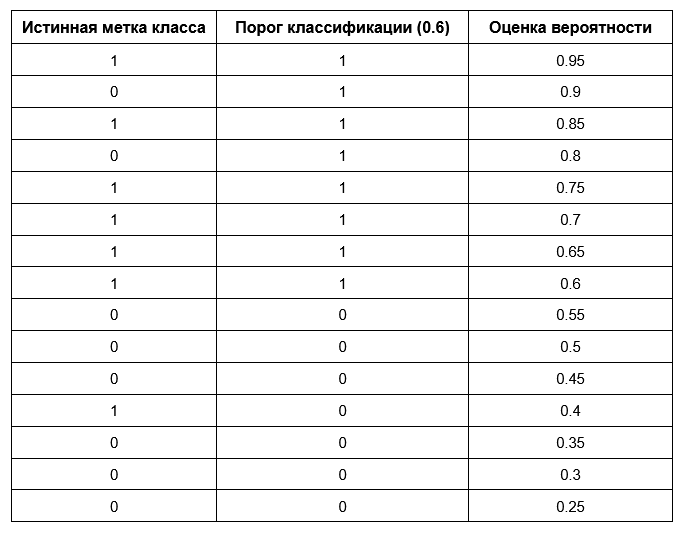




```
TP = 6  FN = 1
FP = 2  TN = 6

TPR = TP/(TP + FN) = 6/7
FPR = FP/(FP + TN) = 2/8
TPR - FPR = 0.739
```



## Задание 3: Ручной счёт корреляции
Рассчитайте линейную корреляцию Пирсона, на основе данных.
Какой вывод можно сделать на основе полученного результата? Можно ли утверждать, что существует причинно-следственная связь между количеством чашек кофе, выпитых студентами в течение экзаменационного дня, и их итоговым баллом за экзамен?
Ответ округлить до сотых, например: 4,12
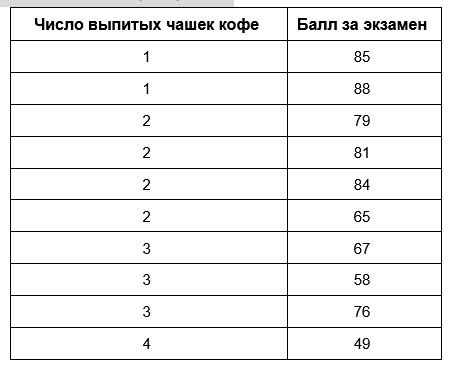

### Ответ: -0,85; Можно утверждать, что присутствует корреляция, но связаны ли два признака - нет.